In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
sys.path.append(f"{global_path}/SS-HSU_benchmark")

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

dev = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(dev)
print(f"Using device: {dev}")

Using device: cuda:0


In [37]:
dataset = "apex"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

In [38]:
fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

### OG

In [39]:
# n_xp = 15
# mses, sads = [], []
# E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
# loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

# for i in range(n_xp):
#     print(f"training {i+1}/{n_xp}")

#     model = unmx.UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=1, kernel_size=1)
#     model.apply(model.weights_init)
#     model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

#     epochs, lr = 200, 0.002
#     optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.18)

#     for _ in range(epochs):

#         for Y, _, _ in loader:
        
#             optimizer.zero_grad()

#             Y = utils.oneD_to_2d(Y).to(dev)

#             _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
#             Y_fm = rsfm.reshape_Y(fm_name, Y, new_H)

#             E_hat, A_hat, Y_hat = model(features)

#             loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
#             loss.backward()
#             nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
#             optimizer.step()
            
#             with torch.no_grad():
#                 constraints = models.weightConstraint()
#                 model.decoder.apply(constraints)
    
#     model.eval()
    
#     with torch.no_grad():
        
#         _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
#         Y_fm, A_init_fm = rsfm.reshape_Y(fm_name, Y, new_H, A_init)
#         E_hat, A_hat, _ = model(features)

#         sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
#         print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
#         mses.append(mse)
#         sads.append(sad)

#     E_hats[i] = E_hat
#     A_hats[i] = A_hat.squeeze(0)

# E_hat_m = torch.mean(E_hats, dim=0)
# A_hat_m = torch.mean(A_hats, dim=0)
# sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
# print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")

### Modified

In [40]:
class Abundance_estimator(nn.Module):
    def __init__(self, D, c, dim=64):
        super(Abundance_estimator, self).__init__()
        dropout = 0.2
        # self.abundance_estimator = nn.Sequential(
        #     nn.Conv2d(D, dim, kernel_size=1, bias=False, padding="same"),
        #     nn.SiLU(),
        #     nn.GroupNorm(4, dim),
        #     nn.Dropout(dropout),
        #     nn.Conv2d(dim, 128, kernel_size=1, bias=False, padding="same"),
        #     nn.SiLU(),
        #     nn.GroupNorm(4, 128),
        #     nn.Dropout(dropout),
        #     nn.Conv2d(128, c, kernel_size=1, bias=False, padding="same"),
        #     nn.SiLU(),
        #     nn.BatchNorm2d(c),
        #     nn.Dropout(dropout)
        # )

        self.abundance_estimator = nn.Sequential(
            nn.Conv2d(D, c, kernel_size=1, bias=False, padding="same"),
            nn.LeakyReLU(0.02),
            nn.BatchNorm2d(c),
            nn.Dropout(dropout)
        )
    
    def forward(self, up_feat):
        return self.abundance_estimator(up_feat)

In [41]:
class UnmixingFromFeatures(nn.Module):
    def __init__(self, D, B, c, H=224, alpha=None, dim=64):

        super(UnmixingFromFeatures, self).__init__()
        self.D = D
        self.alpha = alpha
        self.B = B
        self.c = c
        self.H = H

        # Upsampling features
        self.upsample = nn.Linear(self.alpha**2, self.H**2, bias=False)

        # Upsampled features to abundances
        # self.abundance_estimator = unmx.Abundance_estimator(self.D, self.c, 1, kernel_size=1)
        self.abundance_estimator = Abundance_estimator(self.D, self.c, dim)

        self.sum_to_one = unmx.Sum_to_one(scale=1)
        
        self.decoder = unmx.Decoder(B=B, c=c)

        # num_queries_times = 50
        # self.num_queries = num_queries_times * c
        # self.query_embed = nn.Embedding(self.num_queries, B)
        # self.weights = nn.Parameter(torch.ones((c, num_queries_times)))

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_mse=0.09):
        sad = losses.SADLoss()
        mse = nn.MSELoss(reduction='sum')

        # Reconstruction error
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        # Regularisation
        loss_tv_e = W_tv_e * (torch.abs(E_hat[:, 1:] - E_hat[:, :-1]).sum())
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        loss = loss_sad + loss_ab + loss_tv_e + loss_mse

        return loss

    def get_abundances(self, features):

        features_up = self.upsample(features)
        features_up = utils.oneD_to_2d(features_up).unsqueeze(0)
        features_up = utils.standardise(features_up)
        A_hat = self.abundance_estimator(features_up)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        # query_embed_weight_split = torch.chunk(self.query_embed.weight, self.c, dim=0)
        # query_embed_weight_split = torch.stack(query_embed_weight_split)
        # E_hat = self.weights.unsqueeze(-1).repeat(1, 1, self.B) * query_embed_weight_split
        # E_hat = torch.mean(E_hat, dim=1).T
        # return E_hat
        return self.decoder.get_endmembers()
    
    def forward(self, features):
        A_hat = self.get_abundances(features)
        # Y_hat = self.decoder(A_hat)
        E_hat = self.get_endmembers()
        Y_hat = torch.einsum('Bchw,bc->Bbhw', [A_hat, E_hat])

        return E_hat, A_hat, Y_hat

training 1/15
Current SAD = 0.243, NMSE = 0.246
training 2/15
Current SAD = 0.243, NMSE = 0.255
training 3/15
Current SAD = 0.243, NMSE = 0.232
training 4/15
Current SAD = 0.243, NMSE = 0.260
training 5/15
Current SAD = 0.243, NMSE = 0.265
training 6/15
Current SAD = 0.243, NMSE = 0.244
training 7/15
Current SAD = 0.243, NMSE = 0.282
training 8/15
Current SAD = 0.243, NMSE = 0.251
training 9/15
Current SAD = 0.243, NMSE = 0.248
training 10/15
Current SAD = 0.243, NMSE = 0.272
training 11/15
Current SAD = 0.243, NMSE = 0.244
training 12/15
Current SAD = 0.243, NMSE = 0.255
training 13/15
Current SAD = 0.243, NMSE = 0.242
training 14/15
Current SAD = 0.243, NMSE = 0.249
training 15/15
Current SAD = 0.243, NMSE = 0.244
Average SAD = 0.243 ± 0.00, NMSE = 0.253 ± 0.01


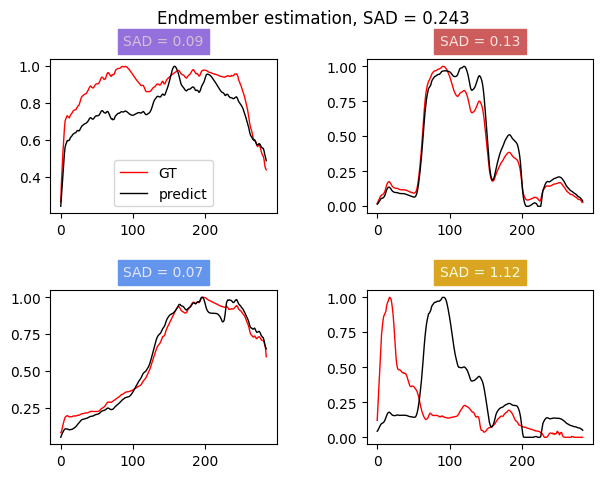

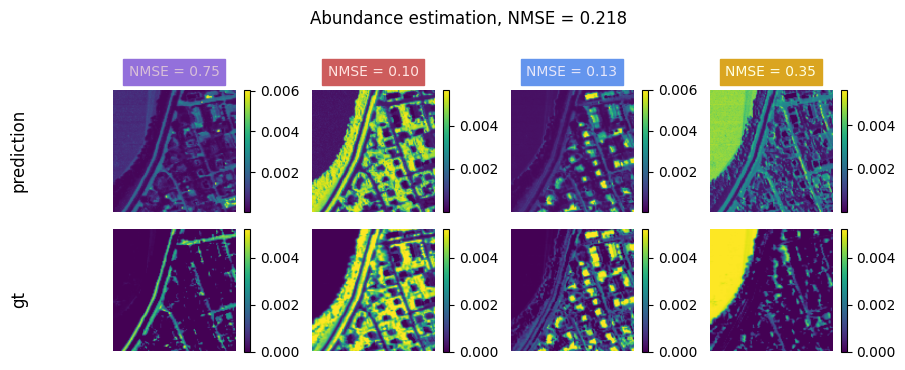

In [42]:
n_xp = 15
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c, dim=48)
    model.apply(model.weights_init)
    if hasattr(model, "decoder"):
        model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.18)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)

            _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
            Y_fm = rsfm.reshape_Y(fm_name, Y, new_H)

            E_hat, A_hat, Y_hat = model(features)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()

                    
            if hasattr(model, "decoder"):  
                with torch.no_grad():
                    constraints = models.weightConstraint()
                    model.decoder.apply(constraints)
            else:
                for p in model.query_embed.weight:
                    p.data.clamp_(1e-7, 1)
    
    model.eval()
    
    with torch.no_grad():
        
        _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
        Y_fm, A_init_fm = rsfm.reshape_Y(fm_name, Y, new_H, A_init)
        E_hat, A_hat, _ = model(features)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")